In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [35]:
DATASET = Path("../backend/app/datasets/matching_dataset.csv")

df = pd.read_csv(DATASET)

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(3304, 28)


,resume_name,job_id,company,title,matched_skill_count,missing_skill_count,resume_skill_count,job_skill_count,skill_overlap_ratio,experience_gap,education_gap,project_match_count,certification_match_count,skill_score,education_score,experience_score,project_score,certification_score,overall_score,confidence,recommendation,matched_skills,missing_skills,retrieval_score,title_similarity,keyword_similarity,technical_job_score,label
0,28320387.pdf,2826285517,Butler University,"Assistant Director of Admission, Midwest Regio...",3,10,5,13,0.2308,1,0,2,0,23.08,100.0,0.0,15.38,0,26.92,Low,Not Recommended,"Communication, Make, Leadership","Amazon Neptune, Automated Testing, iOS SDK, HI...",0.2437,0.0,0.0276,8.0,0
1,14206561.pdf,56924323,NaN,Structural Engineer,1,4,1,5,0.2000,0,0,0,1,20.00,100.0,100.0,0.00,20,46.00,Low,Not Recommended,Excel,"Retrofit, Amazon Neptune, Automated Testing, i...",0.3605,0.0,0.0094,20.0,1
2,15941675.pdf,3045980831,Armstrong Builders LLC,Project Engineer,1,3,5,4,0.2500,0,0,0,0,25.00,100.0,100.0,0.00,0,46.25,Low,Not Recommended,Communication,"Mobile Security, Automated Testing, Attention ...",0.3758,0.0,0.0156,28.0,1
3,28628090.pdf,121605673,NaN,Licensed Acupuncturist,2,6,14,8,0.2500,0,0,2,0,25.00,100.0,100.0,25.00,0,48.75,Low,Not Recommended,"Communication, D","Reverse Engineering, Amazon Neptune, iOS SDK, ...",0.4129,0.0,0.0075,0.0,1
4,13264796.pdf,2147609929,The Job Network,Production Planner,0,11,11,11,0.0000,0,0,1,0,0.00,100.0,100.0,9.09,0,35.91,Low,Not Recommended,NaN,"Mobile Security, Amazon Neptune, Automated Tes...",0.3140,0.0,0.0070,8.0,0


In [36]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 3304 entries, 0 to 3303
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   resume_name                3304 non-null   str    
 1   job_id                     3304 non-null   int64  
 2   company                    2786 non-null   str    
 3   title                      3304 non-null   str    
 4   matched_skill_count        3304 non-null   int64  
 5   missing_skill_count        3304 non-null   int64  
 6   resume_skill_count         3304 non-null   int64  
 7   job_skill_count            3304 non-null   int64  
 8   skill_overlap_ratio        3304 non-null   float64
 9   experience_gap             3304 non-null   int64  
 10  education_gap              3304 non-null   int64  
 11  project_match_count        3304 non-null   int64  
 12  certification_match_count  3304 non-null   int64  
 13  skill_score                3304 non-nul

In [37]:
print("="*60)
print("Statistical Summary")
print("="*60)

df.describe(include="all")

Statistical Summary


,resume_name,job_id,company,title,matched_skill_count,missing_skill_count,resume_skill_count,job_skill_count,skill_overlap_ratio,experience_gap,education_gap,project_match_count,certification_match_count,skill_score,education_score,experience_score,project_score,certification_score,overall_score,confidence,recommendation,matched_skills,missing_skills,retrieval_score,title_similarity,keyword_similarity,technical_job_score,label
count,3304,3.304000e+03,2786,3304,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304,3304,2187,3214,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000
unique,70,NaN,82,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,245,716,NaN,NaN,NaN,NaN,NaN
top,28628090.pdf,NaN,The Job Network,Customer Service Representative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Not Recommended,Communication,"Amazon Neptune, Automated Testing, iOS SDK, Wo...",NaN,NaN,NaN,NaN,NaN
freq,70,NaN,104,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3301,3067,830,63,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.512858e+09,NaN,NaN,0.988801,6.822639,8.458232,7.811441,0.120919,0.698547,0.100787,0.707930,0.136199,12.091916,95.240617,94.521795,10.874252,2.723971,39.991547,NaN,NaN,NaN,NaN,0.341946,0.022553,0.014204,10.943099,0.500000
std,NaN,1.236415e+09,NaN,NaN,0.975415,3.076582,6.511180,3.492717,0.110902,7.683171,0.508314,1.026024,0.443171,11.090175,20.237641,22.597203,18.420196,8.863418,6.917356,NaN,NaN,NaN,NaN,0.049920,0.070803,0.011398,17.663224,0.500076
min,NaN,1.100912e+07,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,NaN,NaN,NaN,NaN,0.170100,0.000000,0.000000,0.000000,0.000000
25%,NaN,2.147610e+09,NaN,NaN,0.000000,5.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,0.000000,0.000000,35.000000,NaN,NaN,NaN,NaN,0.300700,0.000000,0.007500,0.000000,0.000000
50%,NaN,3.177011e+09,NaN,NaN,1.000000,6.000000,6.000000,7.000000,0.125000,0.000000,0.000000,0.000000,0.000000,12.500000,100.000000,100.000000,0.000000,0.000000,40.000000,NaN,NaN,NaN,NaN,0.339850,0.000000,0.014200,0.000000,0.500000
75%,NaN,3.480552e+09,NaN,NaN,1.000000,8.000000,11.000000,9.000000,0.200000,0.000000,0.000000,1.000000,0.000000,20.000000,100.000000,100.000000,16.670000,0.000000,44.170000,NaN,NaN,NaN,NaN,0.371550,0.000000,0.020400,20.000000,1.000000


company            518
matched_skills    1117
missing_skills      90
dtype: int64


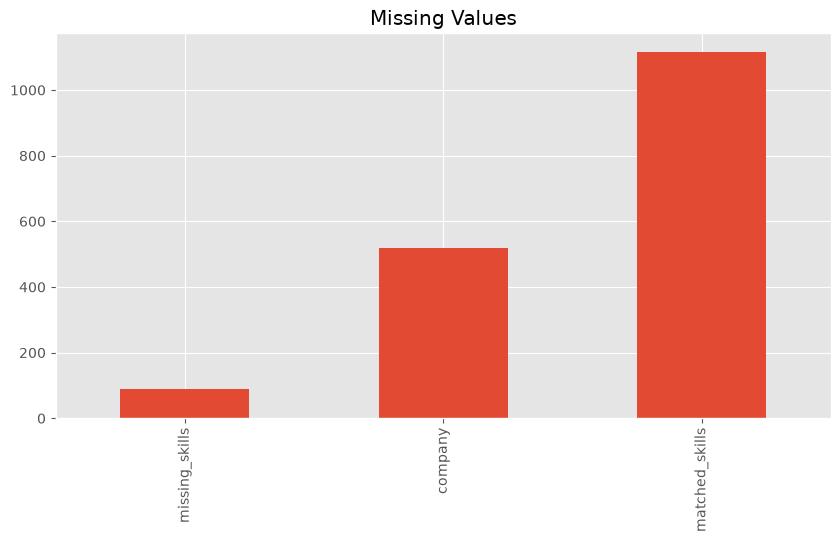

In [38]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if missing.empty:

    print("✅ No missing values found.")

else:

    print(missing)

    plt.figure(figsize=(10,5))

    missing.sort_values().plot.bar()

    plt.title("Missing Values")

    plt.show()

In [39]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [40]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 3304
Columns : 28


In [41]:
df.dtypes

resume_name                      str
job_id                         int64
company                          str
title                            str
matched_skill_count            int64
missing_skill_count            int64
resume_skill_count             int64
job_skill_count                int64
skill_overlap_ratio          float64
experience_gap                 int64
education_gap                  int64
project_match_count            int64
certification_match_count      int64
skill_score                  float64
education_score              float64
experience_score             float64
project_score                float64
certification_score            int64
overall_score                float64
confidence                       str
recommendation                   str
matched_skills                   str
missing_skills                   str
retrieval_score              float64
title_similarity             float64
keyword_similarity           float64
technical_job_score          float64
l

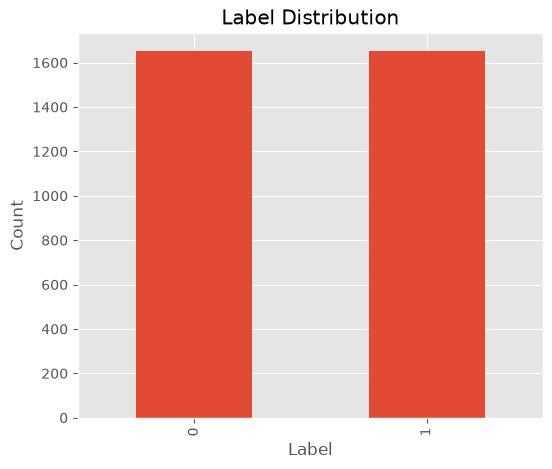

label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [42]:
plt.figure(figsize=(6,5))

df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Label Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

print(df["label"].value_counts(normalize=True))

In [43]:
numerical = df.select_dtypes(include=np.number)

numerical.columns

Index(['job_id', 'matched_skill_count', 'missing_skill_count',
       'resume_skill_count', 'job_skill_count', 'skill_overlap_ratio',
       'experience_gap', 'education_gap', 'project_match_count',
       'certification_match_count', 'skill_score', 'education_score',
       'experience_score', 'project_score', 'certification_score',
       'overall_score', 'retrieval_score', 'title_similarity',
       'keyword_similarity', 'technical_job_score', 'label'],
      dtype='str')

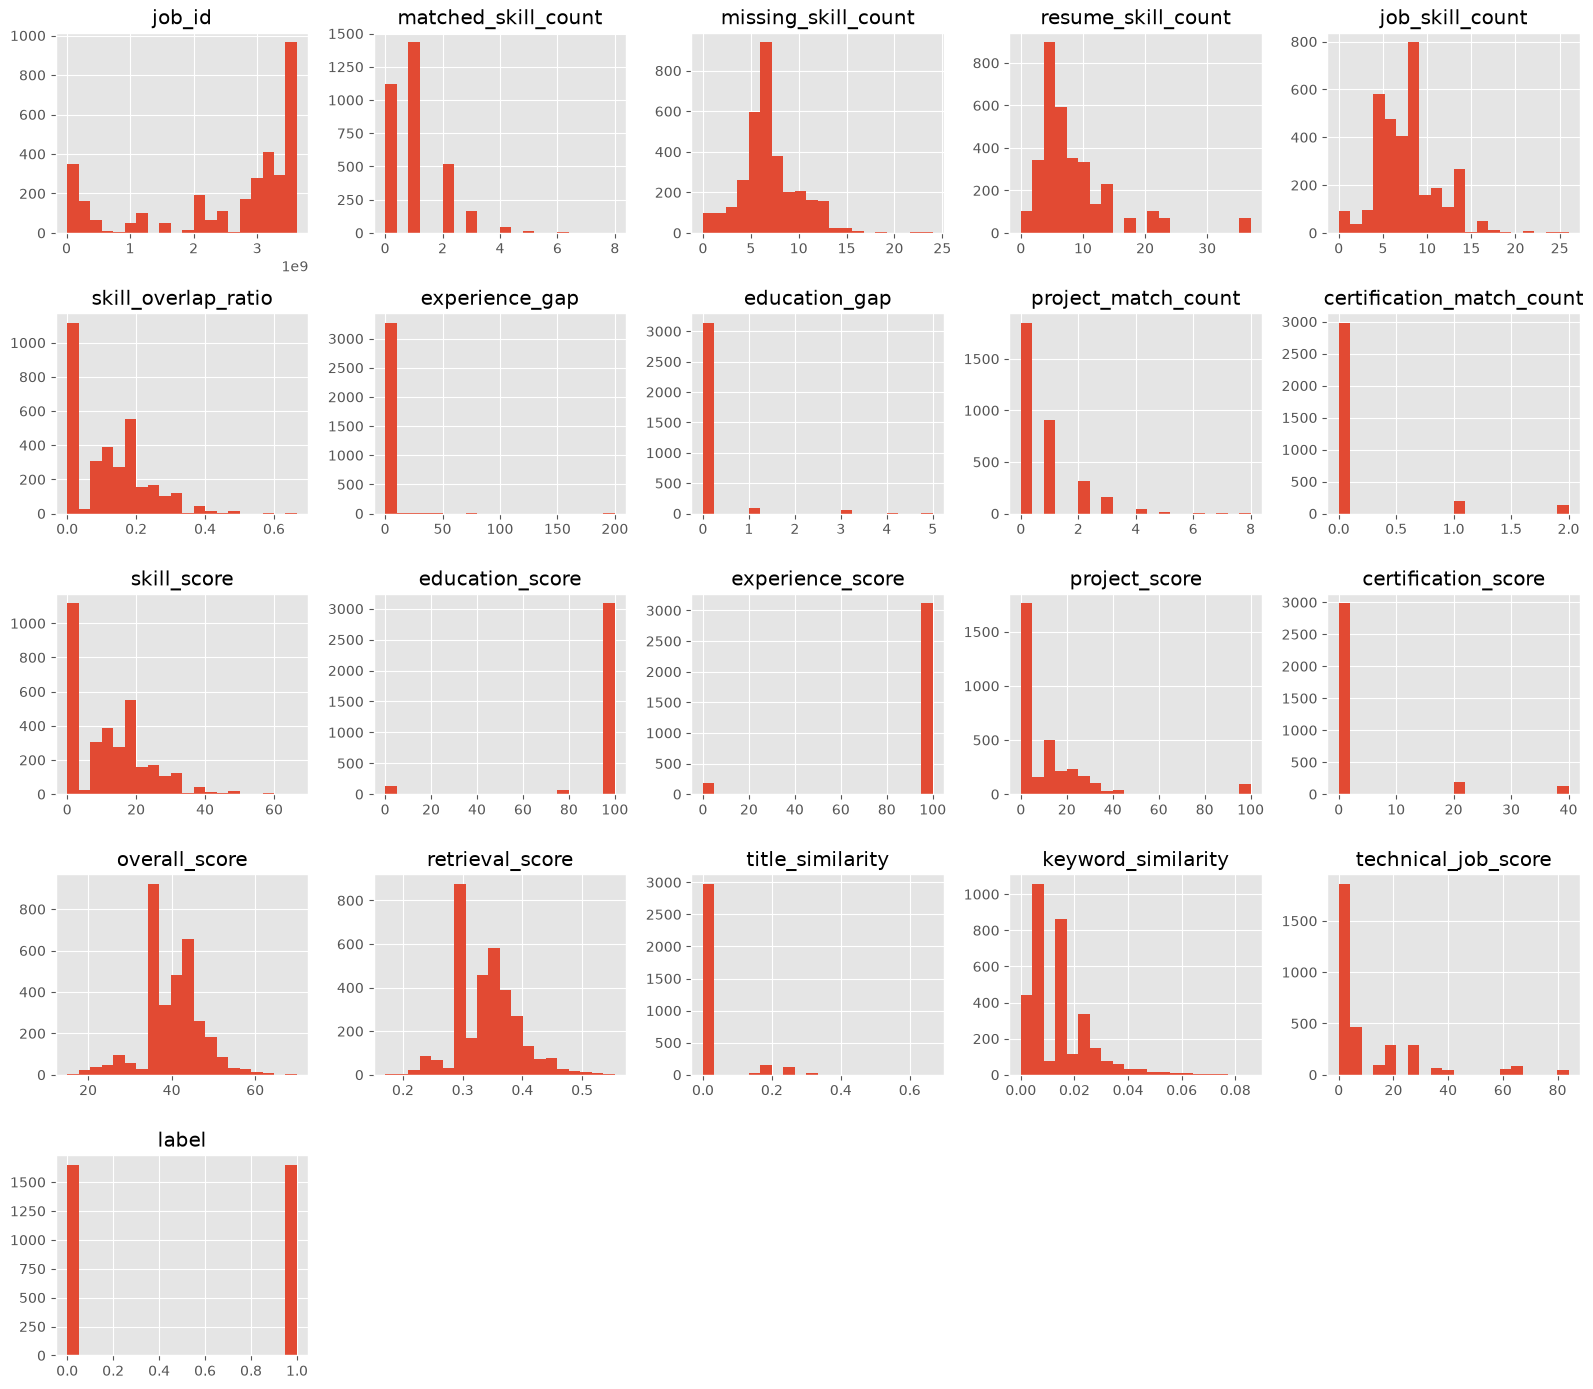

In [44]:
numerical.hist(
    figsize=(16,14),
    bins=20
)

plt.tight_layout()

plt.show()

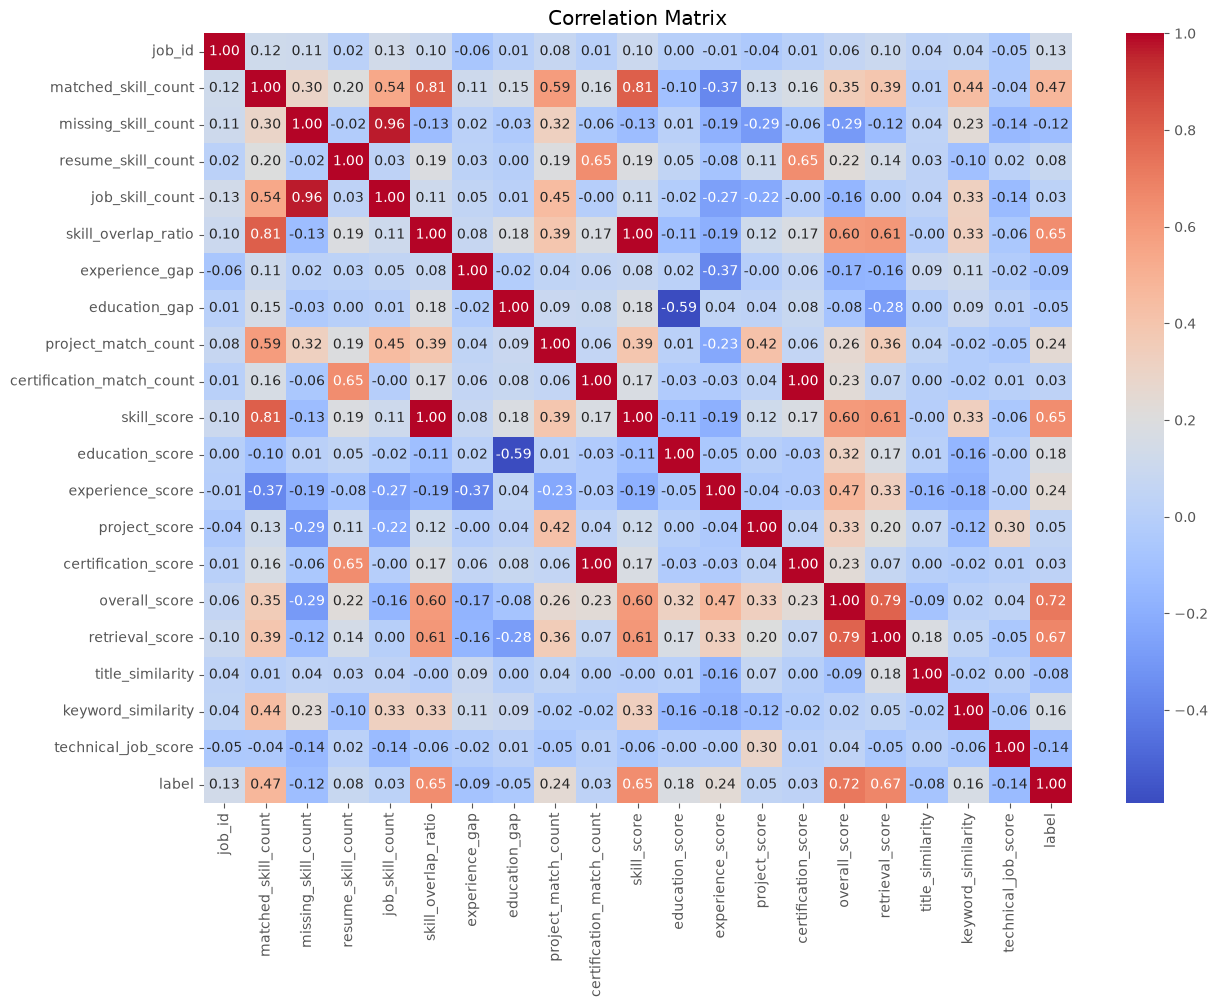

In [45]:
corr = numerical.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

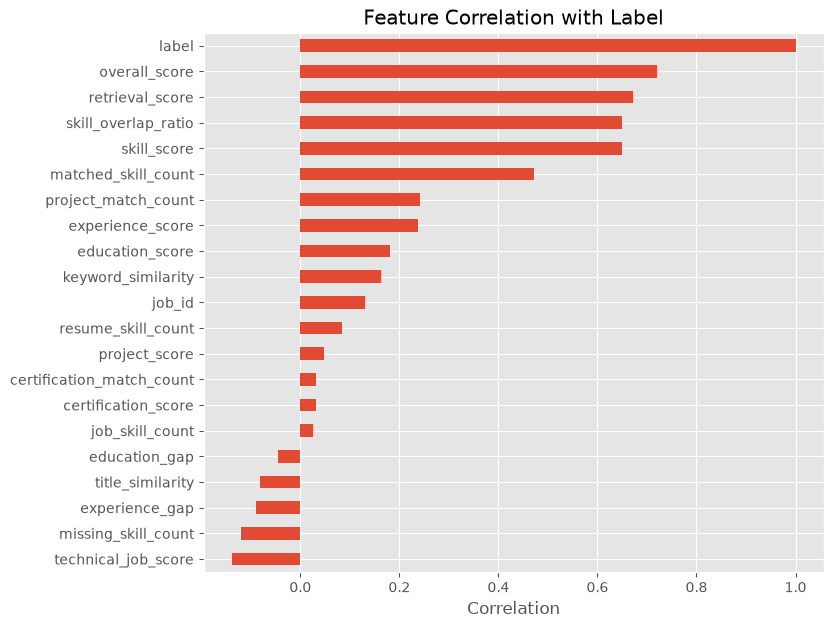

technical_job_score         -0.138131
missing_skill_count         -0.119644
experience_gap              -0.088569
title_similarity            -0.081983
education_gap               -0.045855
job_skill_count              0.026607
certification_score          0.031420
certification_match_count    0.031420
project_score                0.048804
resume_skill_count           0.083218
job_id                       0.131180
keyword_similarity           0.163838
education_score              0.180914
experience_score             0.238357
project_match_count          0.242221
matched_skill_count          0.472646
skill_score                  0.648583
skill_overlap_ratio          0.648583
retrieval_score              0.672659
overall_score                0.720054
label                        1.000000
Name: label, dtype: float64

In [46]:
corr = numerical.corr()["label"].sort_values()

plt.figure(figsize=(8,7))

corr.plot(kind="barh")

plt.title("Feature Correlation with Label")

plt.xlabel("Correlation")

plt.show()

corr

In [47]:
print("Average Feature Values by Label")

df.groupby("label")[FEATURES].mean().T

Average Feature Values by Label


label,0,1
matched_skill_count,0.527845,1.449758
missing_skill_count,7.190678,6.454600
resume_skill_count,7.916465,9.000000
job_skill_count,7.718523,7.904358
skill_overlap_ratio,0.049001,0.192837
experience_gap,1.378935,0.018160
education_gap,0.124092,0.077482
project_match_count,0.459443,0.956416
certification_match_count,0.122276,0.150121
skill_score,4.900109,19.283723


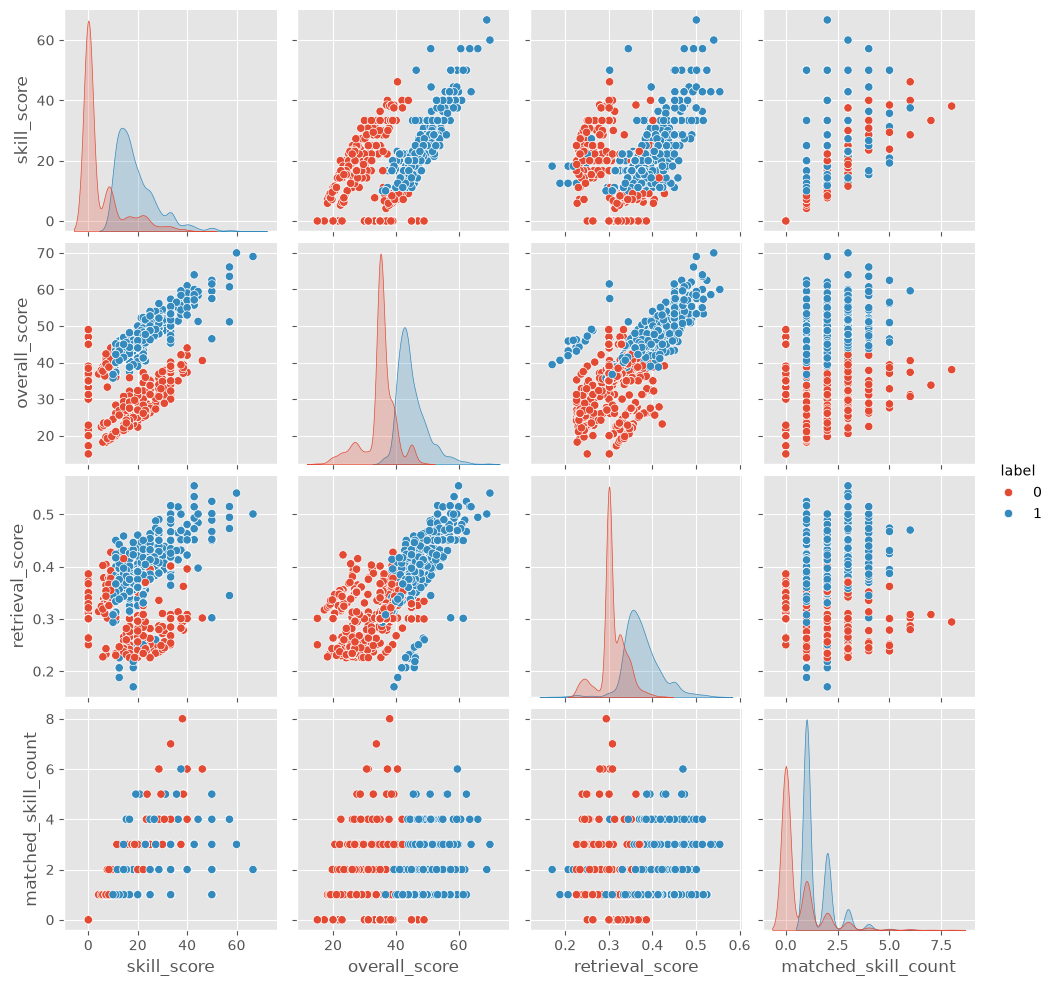

In [48]:
important = [

    "skill_score",

    "overall_score",

    "retrieval_score",

    "matched_skill_count",

    "label"

]

sns.pairplot(

    df[important],

    hue="label"

)

plt.show()

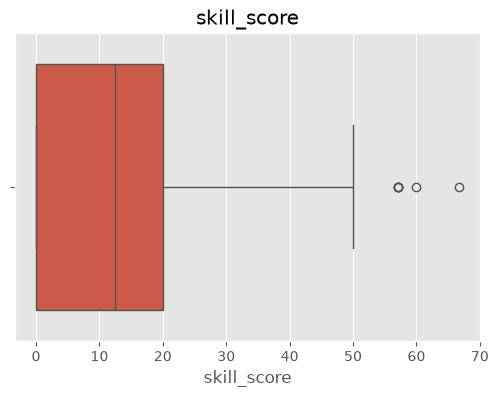

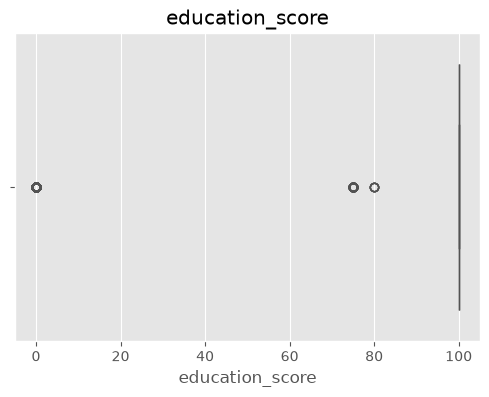

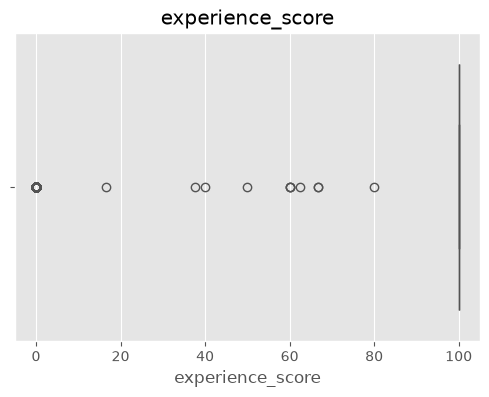

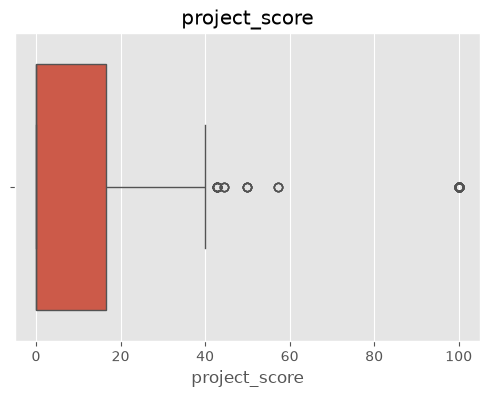

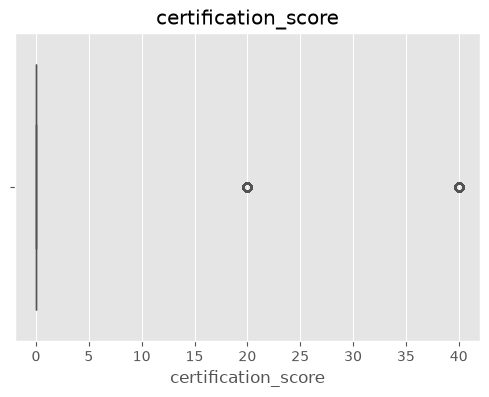

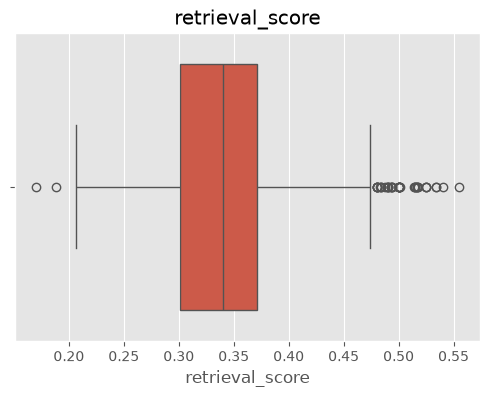

In [49]:
features = [

    "skill_score",

    "education_score",

    "experience_score",

    "project_score",

    "certification_score",

    "retrieval_score"

]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(feature)

    plt.show()

In [50]:
print("Unique Resumes :", df["resume_name"].nunique())

print("Unique Jobs :", df["job_id"].nunique())

print("Unique Companies :", df["company"].nunique())

print("Unique Titles :", df["title"].nunique())

Unique Resumes : 70
Unique Jobs : 100
Unique Companies : 82
Unique Titles : 96


In [51]:
scores = [

    "skill_score",

    "education_score",

    "experience_score",

    "project_score",

    "certification_score",

    "overall_score"

]

df[scores].mean()

skill_score            12.091916
education_score        95.240617
experience_score       94.521795
project_score          10.874252
certification_score     2.723971
overall_score          39.991547
dtype: float64

In [52]:
df["company"].value_counts().head(10)

company
The Job Network             104
San José Clinic              69
Women choice                 68
Food Bank of Alaska          65
Mountain View Eye Center     64
Galerie Candy and Gifts      62
Crisp                        62
Recruitment Design           59
Conduit Tech                 57
LT Apparel Group             53
Name: count, dtype: int64

In [53]:
df["title"].value_counts().head(10)

title
Customer Service Representative                  101
Social Media Coordinator                          90
Software Engineer                                 85
National Sales Manager                            70
Events & Communications Assistant                 69
Summer Intern for Women International Company     68
Chief Operating Officer                           65
Ophthalmic Technician                             64
Quality Assurance Manager                         62
Account Executive - Mid-Market                    62
Name: count, dtype: int64

In [54]:
print("Feature Skewness")

df[FEATURES].skew().sort_values()

Feature Skewness


education_score              -4.367933
experience_score             -3.917795
retrieval_score               0.480812
missing_skill_count           0.699311
skill_score                   0.732660
skill_overlap_ratio           0.732660
job_skill_count               0.792814
matched_skill_count           1.360086
keyword_similarity            1.594222
project_match_count           1.895967
resume_skill_count            2.164625
project_score                 3.189819
title_similarity              3.199664
certification_score           3.329412
certification_match_count     3.329412
education_gap                 5.700756
experience_gap               19.281061
dtype: float64

In [55]:
FEATURES = [

    "matched_skill_count",

    "missing_skill_count",

    "resume_skill_count",

    "job_skill_count",

    "skill_overlap_ratio",

    "experience_gap",

    "education_gap",

    "project_match_count",

    "certification_match_count",

    "skill_score",

    "education_score",

    "experience_score",

    "project_score",

    "certification_score",

    "retrieval_score",

    "title_similarity",

    "keyword_similarity"

]

TARGET = "label"

print(f"Number of Features : {len(FEATURES)}")
print(FEATURES)

Number of Features : 17
['matched_skill_count', 'missing_skill_count', 'resume_skill_count', 'job_skill_count', 'skill_overlap_ratio', 'experience_gap', 'education_gap', 'project_match_count', 'certification_match_count', 'skill_score', 'education_score', 'experience_score', 'project_score', 'certification_score', 'retrieval_score', 'title_similarity', 'keyword_similarity']


In [56]:
X = df[FEATURES]

y = df[TARGET]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

print("\nFeature Data Types")

print(X.dtypes)

print("\nMissing Values")

print(X.isnull().sum())

Feature Matrix Shape : (3304, 17)
Target Shape : (3304,)

Feature Data Types
matched_skill_count            int64
missing_skill_count            int64
resume_skill_count             int64
job_skill_count                int64
skill_overlap_ratio          float64
experience_gap                 int64
education_gap                  int64
project_match_count            int64
certification_match_count      int64
skill_score                  float64
education_score              float64
experience_score             float64
project_score                float64
certification_score            int64
retrieval_score              float64
title_similarity             float64
keyword_similarity           float64
dtype: object

Missing Values
matched_skill_count          0
missing_skill_count          0
resume_skill_count           0
job_skill_count              0
skill_overlap_ratio          0
experience_gap               0
education_gap                0
project_match_count          0
certification_ma

In [61]:
df[scores].mean()


skill_score            12.091916
education_score        95.240617
experience_score       94.521795
project_score          10.874252
certification_score     2.723971
overall_score          39.991547
dtype: float64

In [63]:
print("Average Feature Scores")

display(df[scores].mean().to_frame(name="Average"))

Average Feature Scores


,Average
skill_score,12.091916
education_score,95.240617
experience_score,94.521795
project_score,10.874252
certification_score,2.723971
overall_score,39.991547


In [62]:
print("="*60)
print("Dataset Ready For XGBoost")
print("="*60)

print(f"Training Samples : {len(X)}")
print(f"Number of Features : {X.shape[1]}")
print(f"Target Classes : {sorted(y.unique())}")

print("\nFeature Names:")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Dataset Ready For XGBoost
Training Samples : 3304
Number of Features : 17
Target Classes : [np.int64(0), np.int64(1)]

Feature Names:
1. matched_skill_count
2. missing_skill_count
3. resume_skill_count
4. job_skill_count
5. skill_overlap_ratio
6. experience_gap
7. education_gap
8. project_match_count
9. certification_match_count
10. skill_score
11. education_score
12. experience_score
13. project_score
14. certification_score
15. retrieval_score
16. title_similarity
17. keyword_similarity
